In [1]:
import pandas as  pd
import sklearn 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
pd.pandas.set_option('display.max_columns',None)
from scipy import  stats
from statistics import variance
from imblearn.over_sampling import RandomOverSampler

In [2]:
df= pd.read_csv("b_depressed.csv")

In [3]:
df = df.drop("Ville_id",axis=1)
df = df.drop("Survey_id", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1429 entries, 0 to 1428
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sex                    1429 non-null   int64  
 1   Age                    1429 non-null   int64  
 2   Married                1429 non-null   int64  
 3   Number_children        1429 non-null   int64  
 4   education_level        1429 non-null   int64  
 5   total_members          1429 non-null   int64  
 6   gained_asset           1429 non-null   int64  
 7   durable_asset          1429 non-null   int64  
 8   save_asset             1429 non-null   int64  
 9   living_expenses        1429 non-null   int64  
 10  other_expenses         1429 non-null   int64  
 11  incoming_salary        1429 non-null   int64  
 12  incoming_own_farm      1429 non-null   int64  
 13  incoming_business      1429 non-null   int64  
 14  incoming_no_business   1429 non-null   int64  
 15  inco

In [4]:
df.head()

,sex,Age,Married,Number_children,education_level,total_members,gained_asset,durable_asset,save_asset,living_expenses,other_expenses,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,incoming_agricultural,farm_expenses,labor_primary,lasting_investment,no_lasting_investmen,depressed
0,1,28,1,4,10,5,28912201,22861940,23399979,26692283,28203066,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
1,1,23,1,3,8,5,28912201,22861940,23399979,26692283,28203066,0,0,0,0,30028818,31363432,0,28411718,28292707.0,1
2,1,22,1,3,9,5,28912201,22861940,23399979,26692283,28203066,0,0,0,0,30028818,31363432,0,28411718,28292707.0,0
3,1,27,1,2,10,4,52667108,19698904,49647648,397715,44042267,0,1,0,1,22288055,18751329,0,7781123,69219765.0,0
4,0,59,0,4,10,6,82606287,17352654,23399979,80877619,74503502,1,0,0,0,53384566,20731006,1,20100562,43419447.0,0


## We Will Try To Find:
#### 1.Outliers
#### 2.Missing Values of Numerical Variables
#### 3.Missing Values Of Categorical Data
#### 4. Relationship of variables to the dependent variable 

In [5]:
feature_win_na = [feature for feature in df.columns if df[feature].isnull().sum()>0]



for feature in feature_win_na:
    print(feature, np.round(df[feature].isnull().mean(),4),'% missing values')

no_lasting_investmen 0.014 % missing values


### there was only one variable with outliers no_lasting_investmen

In [6]:
df['no_lasting_investmen'].unique()

array([28292707., 69219765., 43419447., 76629095., 55608922., 54600174.,
       15117619., 20214956., 15708408., 12144989., 71201668., 48624439.,
       12491988., 36790862., 12091604., 26558821., 29246958., 20130429.,
       81077814., 28627474., 35331688., 18484406.,  7572879., 30429201.,
       46671452., 22888632.,  1770199., 41906881., 22430082., 15250636.,
       18927498., 84525561., 14324413.,       nan, 22243569., 53384566.,
       94535172., 10170872., 29265865., 12178354., 24430113.,  2224357.,
       15503545., 38490273., 14235884., 50519592., 17823727., 83101974.,
       66841927., 55875845., 37814068., 24129824.,  2318892., 22145699.,
        6406148., 20352867., 46711497., 37814072., 69177502., 74156723.,
        1442273., 42093727., 29372635., 14280372., 13198221., 93887436.,
       50492902., 48033318., 97871703., 34980236., 63449774., 53810309.,
       14680755., 52717257., 23839546., 48935851., 59523792., 76073008.,
       10147516., 23889594., 87839851., 20023661., 

#### This Are The Most Missing Values in the dataset
#### we will try to find outliers on the next tabs

# 1.Continous Variables

In [7]:
exclude = ["Age","Number_children","total_members","Survey_id","sex","Ville_id","Married","education_level","incoming_salary","incoming_own_farm","incoming_business","incoming_no_business","labor_primary","depressed"]
continuous_features = [feature for feature in df.columns if df[feature].dtypes != 'O' and feature  not in exclude]

print(continuous_features)

['gained_asset', 'durable_asset', 'save_asset', 'living_expenses', 'other_expenses', 'incoming_agricultural', 'farm_expenses', 'lasting_investment', 'no_lasting_investmen']


In [8]:
df[continuous_features].head()


,gained_asset,durable_asset,save_asset,living_expenses,other_expenses,incoming_agricultural,farm_expenses,lasting_investment,no_lasting_investmen
0,28912201,22861940,23399979,26692283,28203066,30028818,31363432,28411718,28292707.0
1,28912201,22861940,23399979,26692283,28203066,30028818,31363432,28411718,28292707.0
2,28912201,22861940,23399979,26692283,28203066,30028818,31363432,28411718,28292707.0
3,52667108,19698904,49647648,397715,44042267,22288055,18751329,7781123,69219765.0
4,82606287,17352654,23399979,80877619,74503502,53384566,20731006,20100562,43419447.0


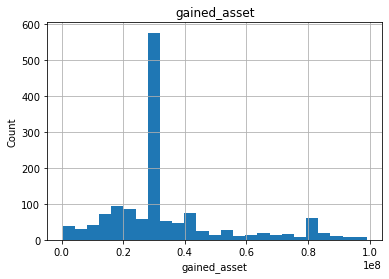

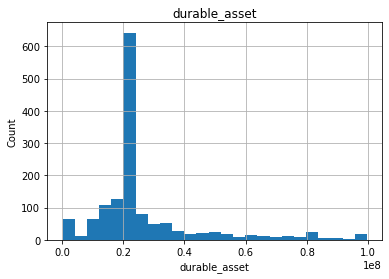

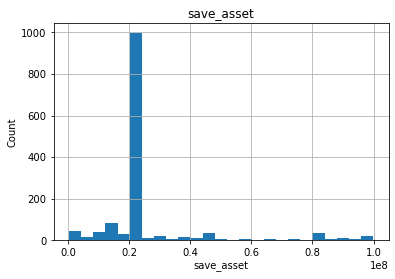

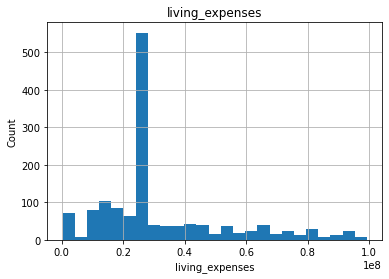

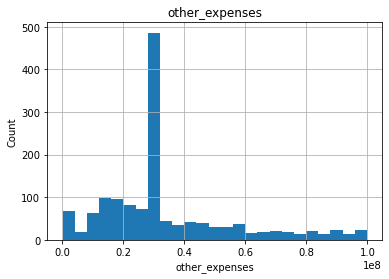

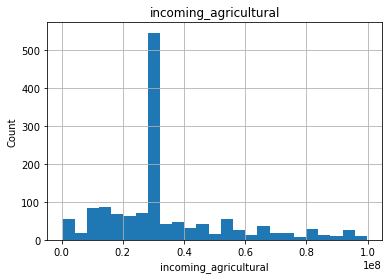

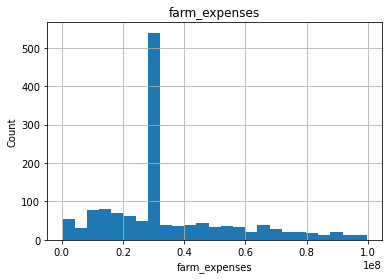

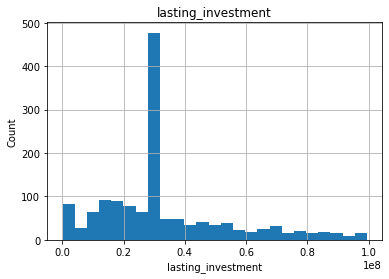

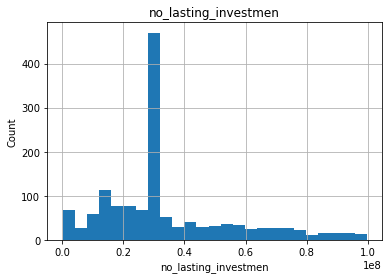

In [9]:

for feature in continuous_features:
    data=df.copy()
    data[feature].hist(bins=25)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature)
    plt.show()

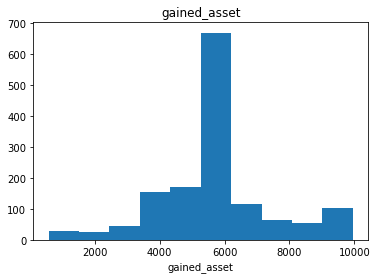

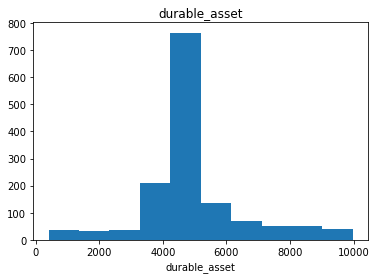

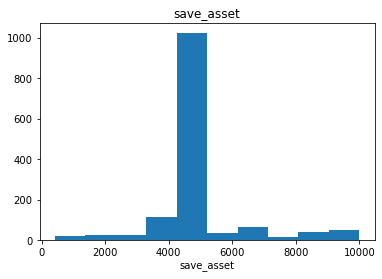

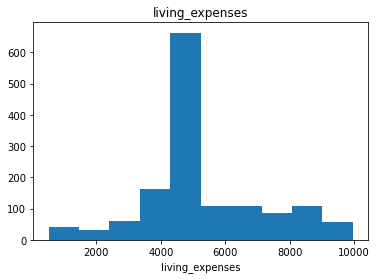

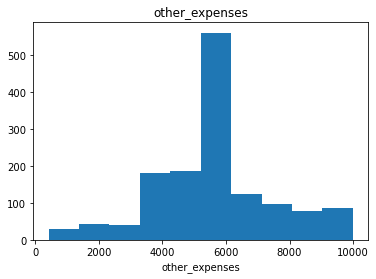

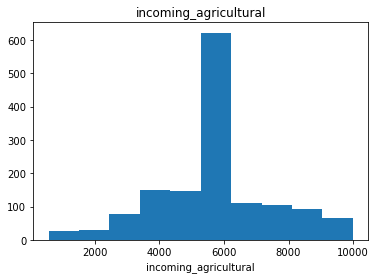

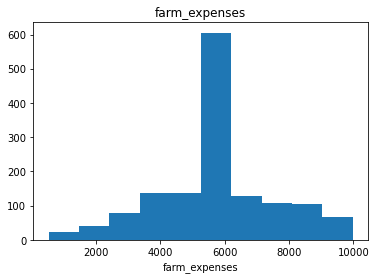

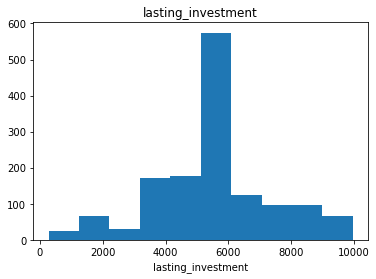

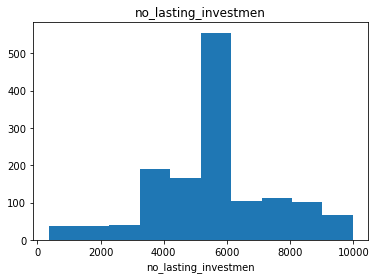

In [10]:
for feature in continuous_features:
    if 0 in df[feature].unique():
        pass
    else:
        df[feature]=np.sqrt(df[feature])
        plt.hist(df[feature])
        plt.xlabel(feature)
        plt.title(feature)
        plt.show()

### data for  continuous variables was cleaned

# 2.Categorical-data 

In [11]:
categorical_variables = ["Married","education_level","incoming_salary","incoming_own_farm", "incoming_business", "incoming_no_business", "labor_primary", "depressed"]

In [12]:
df[categorical_variables].head()

,Married,education_level,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,labor_primary,depressed
0,1,10,0,0,0,0,0,0
1,1,8,0,0,0,0,0,1
2,1,9,0,0,0,0,0,0
3,1,10,0,1,0,1,0,0
4,0,10,1,0,0,0,1,0


# 3.NULL values

In [13]:
for feature in feature_win_na:
    median_value=df[feature].median()
    df[feature].fillna(median_value,inplace=True)
    
df[feature_win_na].isnull().sum()

no_lasting_investmen    0
dtype: int64

# 4.Umbalanced Dependent Variable

<AxesSubplot:ylabel='depressed'>

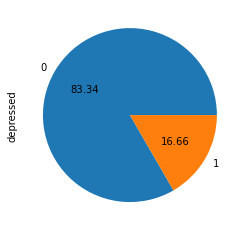

In [14]:
df.depressed.value_counts().plot.pie(autopct='%.2f')

### we have an umbalanced dependent variables 
### I will try to balanced it 

In [15]:
print(df.shape,df.depressed.shape)

(1429, 21) (1429,)


In [16]:
from imblearn.combine import SMOTETomek

smk   = SMOTETomek(random_state=1)

X = df.drop(['depressed'],axis=1)

y = df.depressed

df ,y_os = smk.fit_resample(df,y)



<AxesSubplot:ylabel='depressed'>

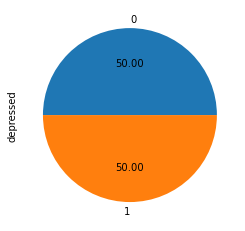

In [17]:
df.depressed.value_counts().plot.pie(autopct='%.2f')

#### here we just have balanced the classes in our dependent variables to perfrom
#### certain tests on them and the independent variables as well

###  import libraries for the prediction here

In [18]:
from sklearn import svm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt

In [19]:
vector_classifier = svm.LinearSVC()

df.head()

,sex,Age,Married,Number_children,education_level,total_members,gained_asset,durable_asset,save_asset,living_expenses,other_expenses,incoming_salary,incoming_own_farm,incoming_business,incoming_no_business,incoming_agricultural,farm_expenses,labor_primary,lasting_investment,no_lasting_investmen,depressed
0,1,28,1,4,10,5,5377.006695,4781.416108,4837.352478,5166.457490,5310.655892,0,0,0,0,5479.855655,5600.306420,0,5330.264346,5319.088926,0
1,1,23,1,3,8,5,5377.006695,4781.416108,4837.352478,5166.457490,5310.655892,0,0,0,0,5479.855655,5600.306420,0,5330.264346,5319.088926,1
2,1,22,1,3,9,5,5377.006695,4781.416108,4837.352478,5166.457490,5310.655892,0,0,0,0,5479.855655,5600.306420,0,5330.264346,5319.088926,0
3,1,27,1,2,10,4,7257.210759,4438.344736,7046.108713,630.646494,6636.434811,0,1,0,1,4721.022665,4330.280476,0,2789.466436,8319.841645,0
4,0,59,0,4,10,6,9088.800086,4165.651690,4837.352478,8993.198486,8631.541114,1,0,0,0,7306.474252,4553.131450,1,4483.365031,6589.343442,0


In [20]:
X = df.drop(df.depressed)
y= df.depressed

y = y[y.index <= 2354 - 1]
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=0)


In [22]:
from sklearn import  metrics

logreg = LogisticRegression()
logreg.fit(x_train,y_train)

score = logreg.score(x_test,y_test)

print(score)


0.8183361629881154


/home/bob/.local/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Test binary model to have a better prediction 